# Auto MPG 연비 예측 Regression Model (모범 답안)

이 파일은 UCI Machine Learning Repository의 Auto MPG 데이터셋을 사용하여 자동차 연비를 예측하는 회귀 모델입니다.
수강생들이 자신의 문제 풀이와 비교하여 학습할 수 있도록 작성되었습니다.

**학습 목표:**
- 신경망 모델을 사용한 회귀 문제 해결
- 데이터 전처리 및 특성 엔지니어링
- 모델 학습 및 평가

### UCI Machine Learning Repository 의 Auto MPG dataset 을 사용하여 자동차 연비 예측 Regression model 작성

- auto-mpg.data - data file  


- auto-mpg.names - data 설명 file

    1. mpg:           continuous  
    2. cylinders:     multi-valued discrete  
    3. displacement:  continuous (배기량)   
    4. horsepower:    continuous  
    5. weight:        continuous  
    6. acceleration:  continuous  
    7. model year:    multi-valued discrete  
    8. origin:        multi-valued discrete, 1 - USA, 2 - Europe, 3 - Japan  
    9. car name:      string (unique for each instance)  

Missing Attribute Values:  horsepower has 6 missing values  ==> "?" 로 들어 있으므로 read_csv 시 nan 으로 변환

## 1. 데이터 로드 및 전처리

필요한 라이브러리를 import 합니다. TensorFlow/Keras를 사용하여 신경망 모델을 구축하고, sklearn을 사용하여 데이터 전처리를 수행합니다.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Auto MPG 데이터셋을 다운로드하고 로드합니다. horsepower 컬럼의 결측값("?")을 na_values로 지정하여 NaN으로 변환합니다.

In [2]:
data_path = keras.utils.get_file("auto-mpg.data",
                                 "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']

rawdata = pd.read_csv(data_path, names=column_names, na_values="?", comment="\t", sep=" ", skipinitialspace=True)

      0/Unknown 0s 0s/step

결측값이 있는 행을 제거하고, 범주형 변수(cylinders, origin)를 원-핫 인코딩으로 변환합니다. 그 다음 타겟 변수(mpg)를 분리하고 데이터를 훈련/테스트 세트로 나눕니다.



In [3]:
rawdata.dropna(inplace=True)

data = rawdata.copy()

data = pd.get_dummies(data, columns=['cylinders', 'origin'])

label = data.pop('mpg')

X_train, X_test, y_train, y_test = train_test_split(data.values, label.values)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((294, 13), (98, 13), (294,), (98,))

StandardScaler를 사용하여 특성을 표준화합니다. 평균 0, 표준편차 1로 정규화하여 모델 학습의 안정성을 높입니다.



In [4]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2. Regression Model Build

Sequential 모델을 생성하고 레이어를 추가합니다. 입력층(13개 특성), 은닉층 2개(32, 64 뉴런), 출력층(1개 뉴런)으로 구성된 신경망을 만듭니다.

In [6]:
model = Sequential([
    Input(shape=(13,)),              # 입력층 명시 (권장 방식)
    Dense(32, activation='relu'),    # 은닉층 1
    Dense(64, activation='relu'),    # 은닉층 2
    Dense(1)                          # 출력층 (회귀 문제)
])

모델을 컴파일합니다. 회귀 문제이므로 손실 함수는 mean_squared_error를 사용하고, 옵티마이저는 adam을 사용합니다.

In [7]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse'])

모델을 학습시킵니다. batch_size=128, epochs=100으로 설정하고, validation_data로 테스트 데이터를 사용하여 검증 손실을 모니터링합니다.

In [8]:
history = model.fit(X_train, y_train, batch_size=128, epochs=100,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 492ms/step - loss: 632.6166 - mse: 632.6166 - val_loss: 519.9607 - val_mse: 519.9607
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 627.4963 - mse: 627.4963 - val_loss: 508.7966 - val_mse: 508.7966
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 617.2668 - mse: 617.2668 - val_loss: 497.5310 - val_mse: 497.5310
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 583.9384 - mse: 583.9384 - val_loss: 486.1140 - val_mse: 486.1140
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 571.8278 - mse: 571.8278 - val_loss: 474.5793 - val_mse: 474.5793
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 562.6831 - mse: 562.6831 - val_loss: 462.7494 - val_mse: 462.7494
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 558.9446 - mse: 558.9446 - val_loss: 450.6115 - val_mse: 450.6115
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 540.6337 - mse: 540.6337 - val_loss: 438.0579 - val_mse: 438.0579
Epoch 9

학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다.

In [9]:
y_predict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


모델의 성능을 평가합니다. R² 점수를 계산하여 모델이 데이터의 분산을 얼마나 잘 설명하는지 확인합니다.

In [10]:
from sklearn.metrics import r2_score

r2_score(y_test, y_predict)

0.7973869068764545

## 3. 결과 시각화

원본 데이터의 처음 5개 행을 확인합니다.

In [11]:
rawdata.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


배기량(displacement)과 연비(mpg)의 관계를 시각화합니다. 실제값과 예측값을 비교하여 모델의 성능을 확인할 수 있습니다.

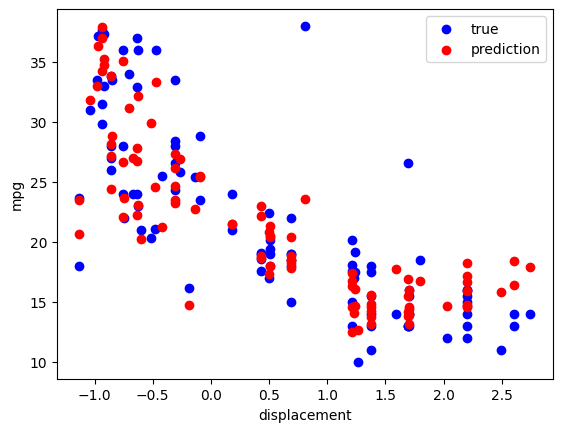

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test, c='b', label="true")
plt.scatter(X_test[:, 0], y_predict, c='r', label="prediction")
plt.xlabel('displacement')
plt.ylabel('mpg')
plt.legend()
plt.show()

실제값과 예측값을 직접 비교하는 산점도를 그립니다. 완벽한 예측이라면 모든 점이 대각선 위에 위치합니다.

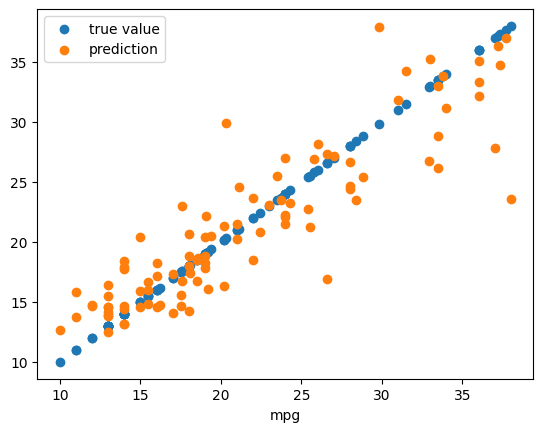

In [13]:
plt.scatter(y_test, y_test, label='true value')
plt.scatter(y_test, y_predict, label='prediction')
plt.xlabel('mpg')
plt.legend()
plt.show()